<a href="https://colab.research.google.com/github/visheshchandrakar/opinionqa-reasoning-homogenization/blob/main/opinionqa_reasoning_analysis_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Does Reasoning Make It Worse? Test-Time Reasoning and Opinion Homogenization
**Term paper analysis notebook — extension of OpinionQA (Santurkar et al., 2023)**

**Research question.** Does letting a language model *think* before answering an opinion question make its answer distribution more diverse (closer to real people) or more collapsed onto one answer?

**Design.** Same weights, only the thinking switch changes (`enable_thinking=True/False`):

| Model | Company | Size | Role |
|---|---|---|---|
| Qwen3-4B | Alibaba | 4B | Primary |
| SmolLM3-3B | Hugging Face | 3B | Replication in a second model family |

For each of N questions sampled from the 15 Pew ATP waves, each model answers K times per condition (temperature 0.6, top-p 0.95 in **both** conditions). The K answers form the model's opinion distribution, which we compare to the weighted distribution of real US respondents.

**Metrics (per question).**
* **Representativeness** $R = 1 - \mathrm{WD}(D_M, D_H) / (n-1)$, the OpinionQA measure (Wasserstein distance on the ordinal answer scale, normalised by the largest possible distance).
* **Normalised entropy** $H(D_M)/\log n$ (1 = spread evenly across all options, 0 = every sample gives the same answer).
* **Modal share**: fraction of samples giving the most common answer (collapse measure).
* **Distinct answers**: number of different options used.
* **Refusal rate** and **parse-failure rate**.

Because the model distribution comes from only K samples, the notebook also computes a **human K-sample baseline**: what these metrics would look like for a perfectly calibrated "model" that draws K answers from the real human distribution. This separates true homogenization from small-sample noise.

---
**How to run**
1. `Runtime → Change runtime type → T4 GPU`.
2. Run the cells in order. Set `SMOKE_TEST = True` first (3 questions, about 5 minutes) to check that everything works, then set it to `False` for the full run.
3. Outputs (raw generations, tables, figures) are saved to Google Drive under `MyDrive/opinionqa_reasoning/`. If Colab disconnects, re-run all cells: finished questions are skipped automatically.

## 1. Configuration

In [1]:
# ---------------- Experiment settings ----------------
MODELS = {
    "Qwen3-4B":   "Qwen/Qwen3-4B",
    "SmolLM3-3B": "HuggingFaceTB/SmolLM3-3B",
}
CONDITIONS = ["no_think", "think"]     # thinking switch off / on

SMOKE_TEST      = False   # True: 3 questions x 3 samples, to test the pipeline. Set False for the real run.
N_QUESTIONS     = 100     # questions sampled from OpinionQA (stratified over the 15 ATP waves)
N_SAMPLES       = 10      # answers per question per condition (20 gives more precise distributions)
TEMPERATURE     = 0.6     # same for both conditions (recommended by both model teams for thinking mode)
TOP_P           = 0.95
TOP_K           = 20
MAX_TOKENS_NO_THINK = 512  # 64 was too short: Qwen3 often explains before giving the letter
MAX_TOKENS_THINK    = 1536   # thinking budget; if the model hits it, it is forced to answer (flagged in the data)
SEED            = 42

ENGINE = "auto"   # "auto": use vLLM if it installs and works on this GPU, else Hugging Face transformers. Or force "vllm" / "hf".
HF_BATCH_SEQS = 30  # sequences generated at once with transformers in no-think mode (think mode uses N_SAMPLES per batch)

# Demographic attributes for the subgroup analysis (see OpinionQA paper, Sec. 4)
GROUP_ATTRS = ["POLIDEOLOGY", "POLPARTY", "EDUCATION", "INCOME", "AGE", "RELIG", "RACE", "SEX"]

USE_DRIVE = False
if SMOKE_TEST:
    N_QUESTIONS, N_SAMPLES = 3, 3

## 2. Setup: Drive, packages, data

In [2]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
BASE_DIR = "/content/opinionqa_reasoning" if IN_COLAB else os.path.abspath("opinionqa_reasoning")
if IN_COLAB and USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = "/content/drive/MyDrive/opinionqa_reasoning"
RUN_TAG  = "smoke" if SMOKE_TEST else f"q{N_QUESTIONS}_k{N_SAMPLES}"
OUT_DIR  = os.path.join(BASE_DIR, RUN_TAG)
GEN_DIR  = os.path.join(OUT_DIR, "generations")
FIG_DIR  = os.path.join(OUT_DIR, "figures")
TAB_DIR  = os.path.join(OUT_DIR, "tables")
DATA_DIR = os.path.join(BASE_DIR, "data")
for d in [OUT_DIR, GEN_DIR, FIG_DIR, TAB_DIR, DATA_DIR]:
    os.makedirs(d, exist_ok=True)
print("Outputs ->", OUT_DIR)

Outputs -> /content/opinionqa_reasoning/q100_k10


In [3]:
if IN_COLAB:
    subprocess.run("pip -q install -U transformers accelerate", shell=True)
    if ENGINE in ("auto", "vllm"):
        # vLLM is much faster, but may not support every Colab GPU / torch combination. We fall back automatically.
        r = subprocess.run("pip -q install vllm", shell=True)
        if r.returncode != 0:
            print("vLLM install failed -> using transformers")
            ENGINE = "hf"
    # Installing vLLM upgrades PyTorch; Colab's preinstalled torchaudio then no longer matches and breaks
    # `import transformers`. Neither model needs torchaudio, so remove it.
    subprocess.run("pip -q uninstall -y torchaudio", shell=True)

In [4]:
import json, re, glob, math, random, tarfile, io, gc, time, ast
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance, wilcoxon, spearmanr
import requests

PEW_SURVEY_LIST = [26, 27, 29, 32, 34, 36, 41, 42, 43, 45, 49, 50, 54, 82, 92]
HUMAN_DIR = os.path.join(DATA_DIR, "human_resp")

### 2.1 Download OpinionQA from CodaLab
The data (≈ 1 GB unpacked) is stored on the CodaLab worksheet of the paper. This cell lists the bundles on the worksheet and downloads the one that contains `human_resp/`. It only runs once; afterwards the data is cached in Drive.

**If the automatic download fails**: open the [worksheet](https://worksheets.codalab.org/worksheets/0x6fb693719477478aac73fc07db333f69), download the data bundle, upload it to `MyDrive/opinionqa_reasoning/data/`, unpack it so that the folder `MyDrive/opinionqa_reasoning/data/human_resp/American_Trends_Panel_W26/` exists, and re-run.

In [5]:
DATA_SOURCE = "auto"   # "auto" | "codalab" | "mirror"
CODALAB = "https://worksheets.codalab.org/rest"
WORKSHEET = "0x6fb693719477478aac73fc07db333f69"
MIRROR_URL = ("https://raw.githubusercontent.com/JosephJeesungSuh/subpop/main/"
              "data/opinionqa/processed/opinionqa.csv")

def parse_list(x):
    if isinstance(x, (list, tuple, np.ndarray)): return list(x)
    try:
        return ast.literal_eval(x)
    except Exception:
        return [float(v) for v in str(x).strip("[]").split()]   # numpy-style "[0.1 0.2]"

def find_human_resp(root):
    hits = glob.glob(os.path.join(root, "**", "American_Trends_Panel_W26", "info.csv"), recursive=True)
    return os.path.dirname(os.path.dirname(hits[0])) if hits else None

def codalab_reachable():
    try:
        requests.get(f"{CODALAB}/worksheets/{WORKSHEET}", timeout=20).raise_for_status()
        return True
    except Exception as e:
        print("CodaLab not reachable:", type(e).__name__)
        return False

def download_codalab():
    r = requests.get(f"{CODALAB}/interpret/worksheet/{WORKSHEET}", timeout=60); r.raise_for_status()
    uuids = [u for u in dict.fromkeys(re.findall(r"0x[0-9a-f]{32}", r.text)) if u != WORKSHEET]
    info = []
    for u in uuids:
        try:
            a = requests.get(f"{CODALAB}/bundles/{u}", timeout=60).json()["data"]["attributes"]
            info.append({"uuid": u, "name": a["metadata"].get("name"), "type": a.get("bundle_type"),
                         "size": a["metadata"].get("data_size") or 0})
        except Exception:
            pass
    cand = pd.DataFrame(info)
    print(cand)
    cand = cand[cand["type"].fillna("").ne("run")].copy()
    cand["score"] = cand["name"].fillna("").str.contains("data|human|opinion", case=False).astype(int)
    for u in cand.sort_values(["score", "size"], ascending=False)["uuid"]:
        try:
            print("Downloading bundle", u)
            with requests.get(f"{CODALAB}/bundles/{u}/contents/blob/", stream=True, timeout=600) as r:
                r.raise_for_status(); buf = io.BytesIO()
                for chunk in r.iter_content(chunk_size=1 << 22): buf.write(chunk)
            buf.seek(0)
            with tarfile.open(fileobj=buf, mode="r:*") as tf: tf.extractall(os.path.join(DATA_DIR, u))
        except Exception as e:
            print("  failed:", e); continue
        if find_human_resp(DATA_DIR): return find_human_resp(DATA_DIR)
    return None

HUMAN_DIR = find_human_resp(DATA_DIR)
if HUMAN_DIR is None and DATA_SOURCE in ("auto", "codalab") and codalab_reachable():
    HUMAN_DIR = download_codalab()
if HUMAN_DIR is not None and DATA_SOURCE != "mirror":
    SOURCE_USED = "codalab"
else:
    assert DATA_SOURCE != "codalab", "CodaLab data not available - set DATA_SOURCE = 'auto' or 'mirror'."
    SOURCE_USED = "mirror"
    MIRROR_PATH = os.path.join(DATA_DIR, "opinionqa_processed.csv")
    if not os.path.exists(MIRROR_PATH):
        r = requests.get(MIRROR_URL, timeout=120); r.raise_for_status()
        open(MIRROR_PATH, "wb").write(r.content)
print("DATA SOURCE USED:", SOURCE_USED)

CodaLab not reachable: ConnectTimeout
DATA SOURCE USED: mirror


### 2.2 Load questions and compute the human opinion distributions
Follows `helpers.extract_human_opinions` from the original repository: survey-weighted answer shares over the ordinal options (refusals are tracked separately).

In [6]:
GROUP_ORDER = {}   # display order of demographic groups, filled below

if SOURCE_USED == "codalab":
    def load_wave(wave):
        d = os.path.join(HUMAN_DIR, f"American_Trends_Panel_W{wave}")
        info = pd.read_csv(os.path.join(d, "info.csv"))
        info["option_ordinal"] = info["option_ordinal"].apply(parse_list)
        info["references"] = info["references"].apply(parse_list)
        info["wave"] = wave
        md = pd.read_csv(os.path.join(d, "metadata.csv"))
        md["options"] = md["options"].apply(parse_list)
        return info, md
    all_info, all_md = [], {}
    for w in PEW_SURVEY_LIST:
        info, md = load_wave(w)
        all_info.append(info); all_md[w] = md
        for k, o in zip(md["key"], md["options"]): GROUP_ORDER.setdefault(k, o)
    info_all = pd.concat(all_info, ignore_index=True).rename(columns={"key": "qkey"})
else:
    mir = pd.read_csv(MIRROR_PATH)
    mir["wave"] = mir["qkey"].str.extract(r"_W(\d+)$")[0].astype(int)
    # a few Pew keys hold several sub-questions -> make a unique id per (key, question text)
    uid = {}
    for (k, qt) in mir[["qkey", "question"]].drop_duplicates().itertuples(index=False):
        n = sum(1 for kk in uid if kk[0] == k)
        uid[(k, qt)] = k if n == 0 else f"{k}#{n + 1}"
    mir["qkey"] = [uid[(k, qt)] for k, qt in zip(mir["qkey"], mir["question"])]
    for c in ["responses", "ordinal", "options"]:
        mir[c] = mir[c].apply(parse_list)
    ov = mir[mir.attribute == "Overall"]
    info_all = pd.DataFrame({"qkey": ov.qkey, "wave": ov.wave, "question": ov.question,
                             "references": ov.options, "option_ordinal": ov.ordinal}).reset_index(drop=True)
    for a, g in mir[mir.attribute != "Overall"].groupby("attribute"):
        GROUP_ORDER[a] = list(dict.fromkeys(g.group))

info_all["n_opts"] = info_all["option_ordinal"].apply(len)
info_all = info_all[(info_all["n_opts"] >= 2) & (info_all["references"].apply(len) >= info_all["n_opts"])]
info_all = info_all.reset_index(drop=True)
print("Questions available:", len(info_all), "from", info_all.wave.nunique(), "waves")

# Stratified sample over waves (fixed seed -> reproducible)
rng = np.random.default_rng(SEED)
per_wave = {w: g for w, g in info_all.groupby("wave")}
quota = {w: N_QUESTIONS // len(per_wave) for w in per_wave}
for w in rng.permutation(list(per_wave))[: N_QUESTIONS - sum(quota.values())]:
    quota[w] += 1
sel = [g.sample(n=min(quota[w], len(g)), random_state=SEED) for w, g in per_wave.items() if quota[w] > 0]
questions = pd.concat(sel).reset_index(drop=True)
print("Sampled questions:", len(questions))

Questions available: 498 from 14 waves
Sampled questions: 100


In [7]:
if SOURCE_USED == "codalab":
    def human_distributions(q_row, resp, md, attrs):
        """Weighted human distribution over ordinal options, overall and per demographic group."""
        wave, qkey = q_row["wave"], q_row["qkey"]
        wkey = f"WEIGHT_W{wave}"
        n_ord = len(q_row["option_ordinal"])
        ord_refs = q_row["references"][:n_ord]
        ref_refs = q_row["references"][n_ord:]
        df = resp[[qkey, wkey] + [a for a in attrs if a in resp.columns]]
        df = df[df[qkey].apply(lambda v: isinstance(v, str))]
        out = []
        def dist_of(sub, attr, group):
            tot = sub.groupby(qkey)[wkey].sum()
            d = np.array([tot.get(o, 0.0) for o in ord_refs], dtype=float)
            if d.sum() == 0: return
            refusal = sum(tot.get(o, 0.0) for o in ref_refs) / tot.sum()
            out.append({"qkey": qkey, "attribute": attr, "group": group, "D_H": d / d.sum(),
                        "R_H": refusal, "n_resp": len(sub)})
        dist_of(df, "Overall", "Overall")
        for a in attrs:
            if a not in df.columns: continue
            opts = md.loc[md["key"] == a, "options"]
            opts = opts.values[0] if len(opts) else sorted(df[a].dropna().unique())
            for g in opts:
                sub = df[df[a] == g]
                if len(sub) >= 30:           # skip tiny groups
                    dist_of(sub, a, g)
        return out

    human_rows = []
    for w, qs in questions.groupby("wave"):
        resp = pd.read_csv(os.path.join(HUMAN_DIR, f"American_Trends_Panel_W{w}", "responses.csv"), low_memory=False)
        for _, q in qs.iterrows():
            human_rows += human_distributions(q, resp, all_md[w], GROUP_ATTRS)
        del resp
    human_df = pd.DataFrame(human_rows)
else:
    h = mir[mir.qkey.isin(questions.qkey) & mir.attribute.isin(["Overall"] + GROUP_ATTRS)]
    human_df = pd.DataFrame({"qkey": h.qkey, "attribute": h.attribute, "group": h.group,
                             "D_H": [np.asarray(r, float) / np.sum(r) for r in h.responses],
                             "R_H": h.refusal_rate}).reset_index(drop=True)

human_overall = human_df[human_df.attribute == "Overall"].drop_duplicates("qkey").set_index("qkey")
questions = questions[questions.qkey.isin(human_overall.index)].reset_index(drop=True)
questions.to_json(os.path.join(OUT_DIR, "questions.jsonl"), orient="records", lines=True)
print(len(questions), "questions,", len(human_df), "human distributions (overall + groups)")
print(questions.groupby("wave").size().to_dict())
questions[["wave", "qkey", "question", "n_opts"]].head()

100 questions, 4396 human distributions (overall + groups)
{26: 7, 29: 7, 32: 7, 34: 7, 36: 7, 41: 7, 42: 8, 43: 8, 45: 7, 49: 7, 50: 7, 54: 7, 82: 7, 92: 7}


,wave,qkey,question,n_opts
0,26,NOCARRYGUN_W26,And would you say you never carry a handgun or...,2
1,26,GUNRESPNOKIDSA_W26,Thinking about gun owners who do not have chil...,4
2,26,SHOOTFREQ_W26,"How often, if ever, do you go shooting or to a...",4
3,26,REASONGUNE_W26,Please indicate whether the following is a maj...,3
4,26,REASONGUNA_W26,Please indicate whether the following is a maj...,3


## 3. Prompting and answer parsing
The prompt follows the OpinionQA default format (question + lettered options including the refusal option), wrapped in each model's chat template. The **only** difference between conditions is `enable_thinking`.

In [8]:
LETTERS = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

def build_user_msg(q):
    opts = "\n".join(f"{LETTERS[i]}. {o}" for i, o in enumerate(q["references"]))
    return (f"Question: {q['question']}\n{opts}\n\n"
            "Answer the question by choosing one of the options above. "
            "Give your final answer in the format 'Answer: <letter>'.")

ANS_PATTERNS = [
    r"answer\s*(?:is)?\s*[:：]?\s*\**\(?([A-Z])\)?\**(?![a-z])",
    r"^\s*\**\(?([A-Z])\)?\**[\.\):]?\s*$",
    r"^\s*\(?([A-Z])[\.\):]\s",
]

def parse_answer(text, q):
    """Returns (letter_index or None, final_text). Uses only the text after </think>."""
    final = text.split("</think>")[-1].strip()
    n = len(q["references"])
    for pat in ANS_PATTERNS:
        m = re.findall(pat, final, flags=re.IGNORECASE | re.MULTILINE)
        m = [x.upper() for x in m if x.upper() in LETTERS[:n]]
        if m:
            return LETTERS.index(m[-1]), final
    # fall back: option text quoted in the answer
    hits = [i for i, o in enumerate(q["references"]) if o.lower() in final.lower()]
    if len(hits) == 1:
        return hits[0], final
    return None, final

# quick self-test of the parser
_q = {"references": ["Yes", "No", "Refused"]}
assert parse_answer("<think>maybe A or B</think>\n\nAnswer: B", _q)[0] == 1
assert parse_answer("A", _q)[0] == 0
assert parse_answer("Answer: **C**", _q)[0] == 2
assert parse_answer("I think the answer is (A).", _q)[0] == 0
assert parse_answer("hmm", _q)[0] is None
print("parser ok")

parser ok


## 4. Generation engines
vLLM when available (fast), otherwise Hugging Face transformers. If a thinking trace hits `MAX_TOKENS_THINK`, we close it with a short forcing string (`budget forcing`) and let the model give its final answer; such samples are flagged `truncated=True` so they can be excluded in a robustness check.

In [9]:
FORCE_SUFFIX = "\n\nI have to give my final answer now.\n</think>\n\nAnswer:"

class HFEngine:
    def __init__(self, repo):
        import torch
        from transformers import AutoTokenizer, AutoModelForCausalLM
        self.torch = torch
        self.tok = AutoTokenizer.from_pretrained(repo)
        self.tok.padding_side = "left"
        if self.tok.pad_token is None:
            self.tok.pad_token = self.tok.eos_token
        dtype = torch.bfloat16 if torch.cuda.get_device_capability()[0] >= 8 else torch.float16  # T4 -> fp16
        self.model = AutoModelForCausalLM.from_pretrained(repo, torch_dtype=dtype, device_map="cuda")
        self.model.eval()

    def _gen(self, prompts, max_new, greedy=False):
        torch = self.torch
        enc = self.tok(prompts, return_tensors="pt", padding=True, add_special_tokens=False).to("cuda")
        with torch.no_grad():
            out = self.model.generate(**enc, max_new_tokens=max_new, do_sample=not greedy,
                                      temperature=TEMPERATURE, top_p=TOP_P, top_k=TOP_K,
                                      pad_token_id=self.tok.pad_token_id)
        gen = out[:, enc["input_ids"].shape[1]:]
        res = []
        for row in gen:
            ids = row.tolist()
            n = len([t for t in ids if t != self.tok.pad_token_id])
            hit_limit = n >= max_new
            res.append((self.tok.decode(row, skip_special_tokens=True), n, hit_limit))
        return res

    def generate(self, prompts, max_new):
        bs = N_SAMPLES if max_new > 200 else HF_BATCH_SEQS
        out = []
        for i in range(0, len(prompts), bs):
            out += self._gen(prompts[i:i + bs], max_new)
        return out

    def close(self):
        del self.model; gc.collect(); self.torch.cuda.empty_cache()

class VLLMEngine:
    def __init__(self, repo):
        # Notebook fixes: run the vLLM engine inside this process, and skip vLLM's stdout redirection
        # (it calls sys.stdout.fileno(), which Jupyter/Colab's stdout does not support).
        os.environ["VLLM_ENABLE_V1_MULTIPROCESSING"] = "0"
        import contextlib
        import vllm.utils.system_utils as _su
        import vllm.distributed.parallel_state as _ps
        _su.suppress_stdout = contextlib.nullcontext
        _ps.suppress_stdout = contextlib.nullcontext
        from vllm import LLM
        from transformers import AutoTokenizer
        self.tok = AutoTokenizer.from_pretrained(repo)
        self.llm = LLM(repo, dtype="half", max_model_len=4096, gpu_memory_utilization=0.9, seed=SEED)

    def generate(self, prompts, max_new):
        from vllm import SamplingParams
        sp = SamplingParams(temperature=TEMPERATURE, top_p=TOP_P, top_k=TOP_K, max_tokens=max_new, seed=None)
        outs = self.llm.generate(prompts, sp, use_tqdm=False)
        return [(o.outputs[0].text, len(o.outputs[0].token_ids), o.outputs[0].finish_reason == "length") for o in outs]

    def close(self):
        import torch
        try:
            from vllm.distributed.parallel_state import destroy_model_parallel
            destroy_model_parallel()
        except Exception:
            pass
        del self.llm; gc.collect(); torch.cuda.empty_cache()

def make_engine(repo):
    global ENGINE
    if ENGINE in ("auto", "vllm"):
        try:
            return VLLMEngine(repo)
        except Exception as e:
            print("vLLM unavailable (", type(e).__name__, str(e)[:200], ") -> transformers")
            ENGINE = "hf"
    return HFEngine(repo)

def chat_prompt(tok, q, think):
    msgs = [{"role": "user", "content": build_user_msg(q)}]
    return tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True, enable_thinking=think)

## 5. Run the experiment
One JSONL file per model × condition. Each line = one sample. Already finished questions are skipped, so this cell can be re-run after a disconnect.

In [10]:
def gen_path(model_name, cond):
    return os.path.join(GEN_DIR, f"{model_name}__{cond}.jsonl")

def done_qkeys(path):
    if not os.path.exists(path): return set()
    cnt = {}
    with open(path) as f:
        for line in f:
            r = json.loads(line); cnt[r["qkey"]] = cnt.get(r["qkey"], 0) + 1
    return {k for k, v in cnt.items() if v >= N_SAMPLES}

def run_condition(engine, model_name, cond, qs):
    think = cond == "think"
    path = gen_path(model_name, cond)
    done = done_qkeys(path)
    todo = [q for q in qs if q["qkey"] not in done]
    print(f"{model_name} / {cond}: {len(done)} done, {len(todo)} to go")
    chunk = 5 if think else 20                      # questions per call (and per checkpoint)
    max_new = MAX_TOKENS_THINK if think else MAX_TOKENS_NO_THINK
    t0 = time.time()
    for i in range(0, len(todo), chunk):
        block = todo[i:i + chunk]
        prompts, meta = [], []
        for q in block:
            p = chat_prompt(engine.tok, q, think)
            prompts += [p] * N_SAMPLES
            meta += [(q, s) for s in range(N_SAMPLES)]
        outs = engine.generate(prompts, max_new)
        # budget forcing for traces that ran out of tokens without finishing thinking
        need = [j for j, (txt, n, lim) in enumerate(outs) if think and lim and "</think>" not in txt]
        forced = {}
        if need:
            extra = engine.generate([prompts[j] + outs[j][0] + FORCE_SUFFIX for j in need], 16)
            forced = {j: FORCE_SUFFIX + extra[k][0] for k, j in enumerate(need)}
        with open(path, "a") as f:
            for j, ((q, s), (txt, n, lim)) in enumerate(zip(meta, outs)):
                full = txt + forced.get(j, "")
                idx, final = parse_answer(full, q)
                think_txt = full.split("</think>")[0] if "</think>" in full else ""
                f.write(json.dumps({
                    "model": model_name, "condition": cond, "qkey": q["qkey"], "sample": s,
                    "answer_idx": idx, "n_opts": len(q["option_ordinal"]), "n_refs": len(q["references"]),
                    "n_gen_tokens": n, "think_chars": len(think_txt.replace("<think>", "").strip()),
                    "truncated": j in forced, "raw": full[-4000:],
                }) + "\n")
        el = time.time() - t0
        print(f"  {min(i + chunk, len(todo))}/{len(todo)} questions  ({el/60:.1f} min)")

qs_records = questions.to_dict("records")
for model_name, repo in MODELS.items():
    if all(len(done_qkeys(gen_path(model_name, c))) >= len(qs_records) for c in CONDITIONS):
        print(model_name, "already complete"); continue
    engine = make_engine(repo)
    print("Engine:", type(engine).__name__)
    for cond in CONDITIONS:
        run_condition(engine, model_name, cond, qs_records)
    engine.close(); del engine; gc.collect()
    if ENGINE != "hf":
        print("NOTE: vLLM does not always free GPU memory. If the next model fails to load, "
              "Runtime → Restart session and re-run all cells (finished work is kept).")

Qwen3-4B already complete


INFO 09-25 19:15:20 [api_utils.py:286] non-default args: {'dtype': 'half', 'seed': 42, 'max_model_len': 4096, 'gpu_memory_utilization': 0.9, 'disable_log_stats': True, 'model': 'HuggingFaceTB/SmolLM3-3B'}
WARNING 09-25 19:15:21 [arg_utils.py:1812] The global random seed is set to 42. Since VLLM_ENABLE_V1_MULTIPROCESSING is set to False, this may affect the random state of the Python process that launched vLLM.
INFO 09-25 19:15:21 [model.py:692] Resolved architecture: SmolLM3ForCausalLM
WARNING 09-25 19:15:21 [model.py:2364] Casting torch.bfloat16 to torch.float16.
INFO 09-25 19:15:21 [model.py:2030] Using max model len 4096
INFO 09-25 19:15:21 [scheduler.py:288] Chunked prefill is enabled with max_num_batched_tokens=8192.


Parse safetensors files:   0%|          | 0/2 [00:00<?, ?it/s]

INFO 09-25 19:15:23 [kernel.py:416] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'], gelu_and_mul_sparse=['triton', 'native'])
INFO 09-25 19:15:28 [core.py:123] Initializing a V1 LLM engine (v0.30.0) with config: model='HuggingFaceTB/SmolLM3-3B', speculative_config=None, tokenizer='HuggingFaceTB/SmolLM3-3B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=main, tokenizer_revision=main, trust_remote_code=False, dtype=torch.float16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, quantization_config=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_any_whitespace=False, disable_additional_proper

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


...

Capturing CUDA graphs (FULL): 100%|██████████| 2/2 [00:00<00:00,  6.64it/s]

INFO 09-25 19:16:48 [model_runner.py:1066] Graph capturing finished in 13 secs, took 0.35 GiB


INFO 09-25 19:16:48 [gpu_worker.py:640] Available KV cache memory: 6.14 GiB
INFO 09-25 19:16:48 [gpu_worker.py:655] CUDA graph memory profiling is enabled (default since v0.21.0). The current --gpu-memory-utilization=0.9000 is equivalent to --gpu-memory-utilization=0.8729 without CUDA graph memory profiling. To maintain the same effective KV cache size as before, increase --gpu-memory-utilization to 0.9271. To disable, set VLLM_MEMORY_PROFILER_ESTIMATE_CUDAGRAPHS=0.
INFO 09-25 19:16:48 [kv_cache_utils.py:2395] GPU KV cache size: 89,408 tokens, Maximum concurrency for 4,096 tokens per request: 21.83x
INFO 09-25 19:16:48 [kernel_warmup.py:172] JIT kernel warmup starting.
INFO 09-25 19:16:48 [kernel_warmup.py:185] JIT kernel warmup finished in 0.00s.


Capturing CUDA graphs (FULL): 100%|██████████| 35/35 [00:02<00:00, 12.02it/s]


INFO 09-25 19:17:31 [model_runner.py:1066] Graph capturing finished in 11 secs, took 0.20 GiB
INFO 09-25 19:17:31 [gpu_worker.py:825] CUDA graph pool memory: 0.2 GiB (actual), 0.39 GiB (estimated), difference: 0.19 GiB (94.2%).
INFO 09-25 19:17:31 [gpu_worker.py:888] Free memory on device (14.46/14.56 GiB) on startup. Desired GPU memory utilization is (0.9, 13.11 GiB). Actual usage is 5.97 GiB for consumed memory (weights + non-torch), 1.0 GiB for peak activation, and 0.2 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=6217260340` (5.79 GiB) to fit into requested memory, or `--kv-cache-memory=7670999552` (7.14 GiB) to fully utilize gpu memory. Current kv cache memory in use is 6.14 GiB.
INFO 09-25 19:17:33 [jit_monitor.py:85] Kernel JIT monitor activated; monitored JIT compilations during inference will use mode=warn.
INFO 09-25 19:17:34 [core.py:372] init engine (profile, create kv cache, warmup model) took 88.12 s (compilation: 21.22 s)
INFO 09

### 5.1 Sanity check: look at a few raw outputs

In [11]:
gens = pd.concat([pd.read_json(p, lines=True) for p in sorted(glob.glob(os.path.join(GEN_DIR, "*.jsonl")))],
                 ignore_index=True)
gens = gens[gens.qkey.isin(questions.qkey)]
for (m, c), g in gens.groupby(["model", "condition"]):
    r = g.iloc[0]
    print(f"===== {m} / {c} | parsed answer idx = {r.answer_idx}\n{r.raw[-600:]}\n")

===== Qwen3-4B / no_think | parsed answer idx = 0
Answer: A

===== Qwen3-4B / think | parsed answer idx = 0
but the answer options are A, B, C. So the answer is either A, B, or C. But the user is asking me to choose. Since I don't have personal data, maybe the answer is A. But I'm not sure. 

Alternatively, maybe the answer is C. But that would be if the person refused to answer. However, the question is not asking for a refusal. 

I think the answer is A: Don't want to carry. But I'm not 100% sure. However, given that the question is in a survey format, and the answer options are given, the answer would be A if the person is not carrying because they don't want to. So Answer: A.
</think>

Answer: A

===== SmolLM3-3B / no_think | parsed answer idx = 0
Answer: A. Don't want to carry

===== SmolLM3-3B / think | parsed answer idx = 1
ather because I can't. So the correct answer would be B: Some other reason. Because the reason I don't carry one isn't that I don't want to, but rather that 

## 6. Metrics

In [12]:
def rep_score(d_m, d_h, ordinal):
    """OpinionQA representativeness: 1 - WD / max WD on the ordinal scale."""
    ordinal = np.asarray(ordinal, dtype=float)
    max_wd = abs(ordinal.max() - ordinal.min())
    return 1 - wasserstein_distance(ordinal, ordinal, d_m, d_h) / max_wd

def norm_entropy(p):
    p = np.asarray(p, float); n = len(p); p = p[p > 0]
    return float(-(p * np.log(p)).sum() / np.log(n)) if n > 1 else 0.0

q_by_key = questions.set_index("qkey")
rows = []
for (m, c, qk), g in gens.groupby(["model", "condition", "qkey"]):
    q = q_by_key.loc[qk]
    n_ord = len(q.option_ordinal)
    idx = g.answer_idx.dropna().astype(int)
    ord_ans = idx[idx < n_ord]
    counts = np.bincount(ord_ans, minlength=n_ord).astype(float)
    row = {"model": m, "condition": c, "qkey": qk, "wave": q.wave, "n_opts": n_ord,
           "n_samples": len(g), "parse_fail": g.answer_idx.isna().mean(),
           "refusal": (idx >= n_ord).sum() / len(g), "truncated": g.truncated.mean(),
           "gen_tokens": g.n_gen_tokens.mean(), "think_chars": g.think_chars.mean(), "n_valid": counts.sum()}
    if counts.sum() > 0:
        d_m = counts / counts.sum()
        d_h = human_overall.loc[qk, "D_H"]
        row.update({"rep": rep_score(d_m, d_h, q.option_ordinal), "entropy": norm_entropy(d_m),
                    "modal_share": d_m.max(), "distinct": int((counts > 0).sum()),
                    "human_entropy": norm_entropy(d_h), "D_M": d_m})
    rows.append(row)
qdf = pd.DataFrame(rows)
qdf.drop(columns=["D_M"]).to_csv(os.path.join(TAB_DIR, "per_question_metrics.csv"), index=False)
print(qdf.groupby(["model", "condition"])[["parse_fail", "refusal", "truncated", "n_valid"]].mean().round(3))

                      parse_fail  refusal  truncated  n_valid
model      condition                                         
Qwen3-4B   no_think          0.0    0.029      0.000     9.71
           think             0.0    0.103      0.004     8.97
SmolLM3-3B no_think          0.0    0.001      0.000     9.99
           think             0.0    0.022      0.016     9.78


### 6.1 Human K-sample baseline
A calibrated model that draws K answers from the true human distribution would still look somewhat "collapsed" with K = 10 samples. This Monte-Carlo baseline gives the metric values such a model would get, so model results can be read against it.

In [13]:
def human_sampled_baseline(k, reps=500, seed=SEED):
    rng = np.random.default_rng(seed); out = []
    for _, q in questions.iterrows():
        d_h = human_overall.loc[q.qkey, "D_H"]; n = len(d_h)
        draws = rng.multinomial(k, d_h, size=reps) / k
        out.append({"qkey": q.qkey,
                    "rep": np.mean([rep_score(d, d_h, q.option_ordinal) for d in draws]),
                    "entropy": np.mean([norm_entropy(d) for d in draws]),
                    "modal_share": draws.max(1).mean(),
                    "distinct": (draws > 0).sum(1).mean(),
                    "human_entropy": norm_entropy(d_h)})
    return pd.DataFrame(out)

hbase = human_sampled_baseline(N_SAMPLES)
hbase_true = pd.DataFrame({"qkey": questions.qkey,
                           "entropy": [norm_entropy(human_overall.loc[k, "D_H"]) for k in questions.qkey],
                           "modal_share": [human_overall.loc[k, "D_H"].max() for k in questions.qkey]})
print("Human K-sample baseline (means):\n", hbase[["rep", "entropy", "modal_share", "distinct"]].mean().round(3))
print("True human distribution (means):\n", hbase_true[["entropy", "modal_share"]].mean().round(3))

Human K-sample baseline (means):
 rep            0.902
entropy        0.738
modal_share    0.544
distinct       3.112
dtype: float64
True human distribution (means):
 entropy        0.851
modal_share    0.480
dtype: float64


## 7. Main results: thinking vs. no thinking
Paired by question. For each model and metric: mean in each condition, mean difference (think − no_think) with a 95 % bootstrap CI over questions, Wilcoxon signed-rank test, Holm correction across the metrics of a model.

In [14]:
METRICS = ["rep", "entropy", "modal_share", "distinct", "refusal"]

def boot_ci(x, reps=10000, seed=SEED):
    rng = np.random.default_rng(seed); x = np.asarray(x)
    b = rng.choice(x, size=(reps, len(x)), replace=True).mean(1)
    return np.percentile(b, [2.5, 97.5])

def holm(p):
    p = np.asarray(p, float); o = np.argsort(p); m = len(p); adj = np.empty(m); run = 0
    for r, i in enumerate(o):
        run = max(run, (m - r) * p[i]); adj[i] = min(1, run)
    return adj

def paired_table(qdf):
    res = []
    for m, g in qdf.groupby("model"):
        wide = g.pivot(index="qkey", columns="condition", values=METRICS)
        part = []
        for met in METRICS:
            w = wide[met].dropna()
            if len(w) < 2 or "think" not in w or "no_think" not in w: continue
            d = w["think"] - w["no_think"]
            try: p = wilcoxon(d, zero_method="zsplit").pvalue if (d != 0).any() else 1.0
            except ValueError: p = np.nan
            lo, hi = boot_ci(d)
            part.append({"model": m, "metric": met, "n_q": len(w),
                         "no_think": w["no_think"].mean(), "think": w["think"].mean(),
                         "diff": d.mean(), "ci_low": lo, "ci_high": hi,
                         "share_q_up": (d > 0).mean(), "share_q_down": (d < 0).mean(),
                         "cohen_dz": d.mean() / d.std(ddof=1) if d.std(ddof=1) > 0 else np.nan,
                         "p_wilcoxon": p})
        part = pd.DataFrame(part)
        if len(part): part["p_holm"] = holm(part["p_wilcoxon"].fillna(1))
        res.append(part)
    return pd.concat(res, ignore_index=True)

main = paired_table(qdf)
main.to_csv(os.path.join(TAB_DIR, "main_results.csv"), index=False)
pd.options.display.float_format = "{:.3f}".format
main

,model,metric,n_q,no_think,think,diff,ci_low,ci_high,share_q_up,share_q_down,cohen_dz,p_wilcoxon,p_holm
0,Qwen3-4B,rep,98,0.724,0.717,-0.007,-0.032,0.018,0.316,0.296,-0.055,0.976,0.976
1,Qwen3-4B,entropy,98,0.121,0.194,0.074,0.012,0.136,0.357,0.173,0.233,0.020,0.060
2,Qwen3-4B,modal_share,98,0.928,0.874,-0.054,-0.094,-0.013,0.173,0.357,-0.261,0.013,0.050
3,Qwen3-4B,distinct,98,1.327,1.490,0.163,0.000,0.327,0.286,0.163,0.199,0.081,0.162
4,Qwen3-4B,refusal,100,0.029,0.103,0.074,0.029,0.123,0.240,0.040,0.310,0.002,0.009
5,SmolLM3-3B,rep,99,0.736,0.759,0.023,0.001,0.046,0.465,0.253,0.206,0.021,0.041
6,SmolLM3-3B,entropy,99,0.211,0.344,0.133,0.082,0.186,0.525,0.182,0.494,0.000,0.000
7,SmolLM3-3B,modal_share,99,0.867,0.799,-0.069,-0.105,-0.032,0.192,0.495,-0.365,0.000,0.001
8,SmolLM3-3B,distinct,99,1.525,1.960,0.434,0.303,0.576,0.384,0.040,0.606,0.000,0.000
9,SmolLM3-3B,refusal,100,0.001,0.022,0.021,0.005,0.046,0.080,0.000,0.190,0.140,0.140


### 7.1 Pooled across both models
Question-level differences averaged over the two models: is the direction of the effect shared?

In [15]:
wide_all = qdf.pivot_table(index=["model", "qkey"], columns="condition", values=METRICS)
pooled = []
for met in METRICS:
    d = (wide_all[met]["think"] - wide_all[met]["no_think"]).groupby(level="qkey").mean().dropna()
    if len(d) < 2: continue
    lo, hi = boot_ci(d)
    p = wilcoxon(d, zero_method="zsplit").pvalue if (d != 0).any() else 1.0
    pooled.append({"metric": met, "n_q": len(d), "diff": d.mean(), "ci_low": lo, "ci_high": hi, "p_wilcoxon": p})
pooled = pd.DataFrame(pooled); pooled["p_holm"] = holm(pooled.p_wilcoxon)
pooled.to_csv(os.path.join(TAB_DIR, "pooled_results.csv"), index=False)
pooled

,metric,n_q,diff,ci_low,ci_high,p_wilcoxon,p_holm
0,rep,99,0.008,-0.010,0.026,0.518,0.518
1,entropy,99,0.104,0.060,0.148,0.000,0.000
2,modal_share,99,-0.062,-0.092,-0.033,0.000,0.000
3,distinct,99,0.298,0.187,0.414,0.000,0.000
4,refusal,100,0.048,0.023,0.074,0.001,0.001


### 7.2 Robustness checks
(a) excluding samples where the thinking budget was hit; (b) only questions where both conditions have at least K/2 valid (non-refusal, parsed) answers.

In [16]:
def recompute(gsub):
    rows = []
    for (m, c, qk), g in gsub.groupby(["model", "condition", "qkey"]):
        q = q_by_key.loc[qk]; n_ord = len(q.option_ordinal)
        idx = g.answer_idx.dropna().astype(int); idx = idx[idx < n_ord]
        if len(idx) == 0: continue
        d_m = np.bincount(idx, minlength=n_ord) / len(idx)
        rows.append({"model": m, "condition": c, "qkey": qk, "n_valid": len(idx),
                     "rep": rep_score(d_m, human_overall.loc[qk, "D_H"], q.option_ordinal),
                     "entropy": norm_entropy(d_m), "modal_share": d_m.max(), "distinct": int((d_m > 0).sum()),
                     "refusal": 0.0})
    return pd.DataFrame(rows)

rob_a = paired_table(recompute(gens[~gens.truncated])); rob_a["check"] = "no truncated traces"
ok = qdf[qdf.n_valid >= N_SAMPLES / 2].groupby(["model", "qkey"]).condition.nunique()
ok = ok[ok == 2].reset_index()[["model", "qkey"]]
rob_b = paired_table(qdf.merge(ok)); rob_b["check"] = ">= K/2 valid answers in both"
robust = pd.concat([rob_a, rob_b])
robust = robust[robust.metric != "refusal"]
robust.to_csv(os.path.join(TAB_DIR, "robustness.csv"), index=False)
robust[["check", "model", "metric", "n_q", "diff", "ci_low", "ci_high", "p_holm"]]

,check,model,metric,n_q,diff,ci_low,ci_high,p_holm
0,no truncated traces,Qwen3-4B,rep,98,-0.007,-0.032,0.018,1.000
1,no truncated traces,Qwen3-4B,entropy,98,0.073,0.011,0.135,0.101
2,no truncated traces,Qwen3-4B,modal_share,98,-0.054,-0.095,-0.012,0.080
3,no truncated traces,Qwen3-4B,distinct,98,0.163,0.000,0.327,0.243
5,no truncated traces,SmolLM3-3B,rep,99,0.021,-0.001,0.043,0.063
6,no truncated traces,SmolLM3-3B,entropy,99,0.133,0.081,0.186,0.000
7,no truncated traces,SmolLM3-3B,modal_share,99,-0.070,-0.107,-0.033,0.001
8,no truncated traces,SmolLM3-3B,distinct,99,0.424,0.283,0.566,0.000
0,>= K/2 valid answers in both,Qwen3-4B,rep,91,-0.000,-0.026,0.026,0.610
1,>= K/2 valid answers in both,Qwen3-4B,entropy,91,0.079,0.014,0.146,0.096


### 7.3 Does longer reasoning go with more collapse?
Spearman correlation, across questions, between thinking length and the change in entropy.

In [17]:
th = qdf[qdf.condition == "think"][["model", "qkey", "think_chars"]]
dd = qdf.pivot_table(index=["model", "qkey"], columns="condition", values="entropy").dropna()
dd = (dd["think"] - dd["no_think"]).rename("d_entropy").reset_index().merge(th)
corr = []
for m, g in dd.groupby("model"):
    if len(g) > 3:
        r, p = spearmanr(g.think_chars, g.d_entropy); corr.append({"model": m, "spearman_r": r, "p": p, "n_q": len(g)})
corr = pd.DataFrame(corr); corr.to_csv(os.path.join(TAB_DIR, "length_vs_entropy.csv"), index=False)
corr

,model,spearman_r,p,n_q
0,Qwen3-4B,0.329,0.001,98
1,SmolLM3-3B,0.191,0.059,99


## 8. Subgroup representativeness (whose opinions?)
As in OpinionQA: representativeness of each model/condition with respect to each demographic group. The shift tells us **whose** opinions reasoning moves the model toward.

In [18]:
dm = qdf.dropna(subset=["rep"]).set_index(["model", "condition", "qkey"])["D_M"]
grp = human_df[human_df.attribute != "Overall"]
g_rows = []
for (m, c, qk), d_m in dm.items():
    ordinal = q_by_key.loc[qk, "option_ordinal"]
    for _, h in grp[grp.qkey == qk].iterrows():
        g_rows.append({"model": m, "condition": c, "attribute": h.attribute, "group": h.group,
                       "qkey": qk, "rep": rep_score(d_m, h.D_H, ordinal)})
gdf = pd.DataFrame(g_rows)
group_rep = gdf.groupby(["attribute", "group", "model", "condition"]).rep.mean().unstack(["model", "condition"])
group_rep.to_csv(os.path.join(TAB_DIR, "group_representativeness.csv"))
top = gdf.groupby(["model", "condition", "attribute", "group"]).rep.mean().reset_index()
most = top.loc[top.groupby(["model", "condition", "attribute"]).rep.idxmax()]
most = most.pivot_table(index="attribute", columns=["model", "condition"], values="group", aggfunc="first")
most.to_csv(os.path.join(TAB_DIR, "most_represented_group.csv"))
print("Most represented group per attribute:"); most

Most represented group per attribute:


model                Qwen3-4B                    \
condition            no_think             think   
attribute                                         
AGE                     30-49             18-29   
EDUCATION        Postgraduate      Postgraduate   
INCOME       $100,000 or more  $100,000 or more   
POLIDEOLOGY           Liberal           Liberal   
POLPARTY             Democrat          Democrat   
RACE                    Asian             Asian   
RELIG                 Atheist          Agnostic   
SEX                      Male            Female   

model                            SmolLM3-3B                    
condition                          no_think             think  
attribute                                                      
AGE                                   18-29             18-29  
EDUCATION    College graduate/some postgrad      Postgraduate  
INCOME                      $30,000-$50,000  $100,000 or more  
POLIDEOLOGY                         Liberal           Liberal  
POLPARTY                           Democrat          Democrat  
RACE                                  Asian             Asian  
RELIG                              Agnostic          Agnostic  
SEX                                  Female            Female

## 9. Figures

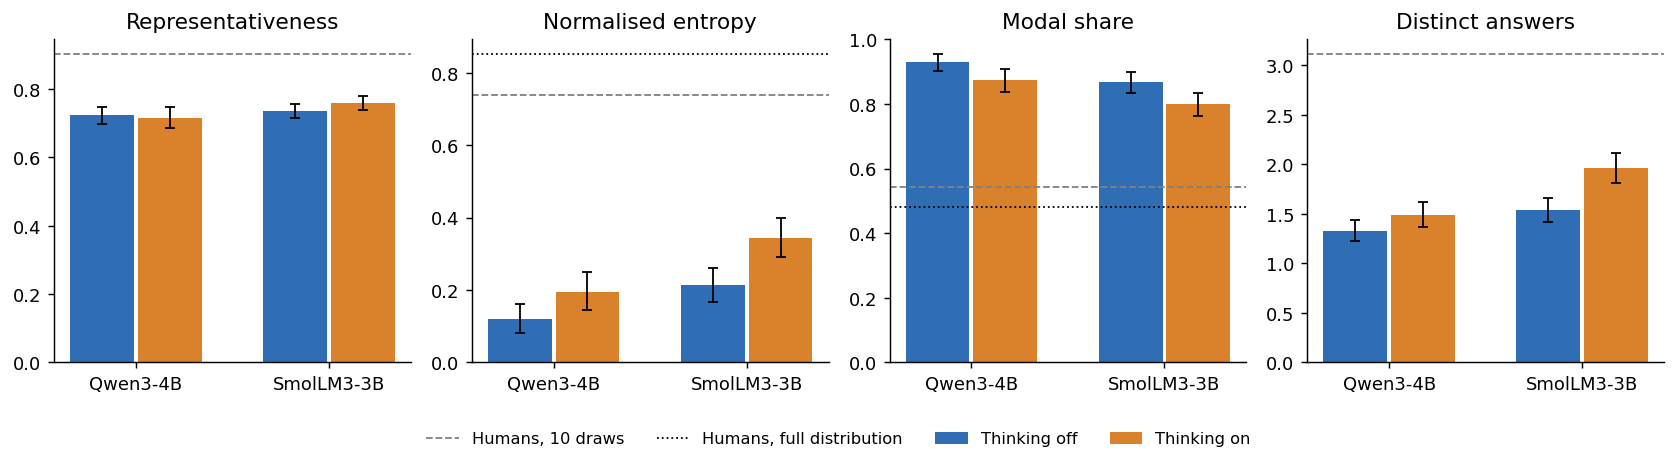

In [19]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"figure.dpi": 130, "savefig.dpi": 300, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
COND_COLOR = {"no_think": "#2F6DB5", "think": "#D9822B"}
COND_LABEL = {"no_think": "Thinking off", "think": "Thinking on"}
MODEL_ORDER = list(MODELS)
LABELS = {"rep": "Representativeness", "entropy": "Normalised entropy",
          "modal_share": "Modal share", "distinct": "Distinct answers"}

def savefig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, name + ".png"), bbox_inches="tight")
    fig.savefig(os.path.join(FIG_DIR, name + ".pdf"), bbox_inches="tight")

# Figure 1: mean metrics with 95% CIs, human K-sample baseline as dashed line
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, met in zip(axes, LABELS):
    for i, m in enumerate(MODEL_ORDER):
        for j, c in enumerate(CONDITIONS):
            v = qdf[(qdf.model == m) & (qdf.condition == c)][met].dropna()
            if not len(v): continue
            lo, hi = boot_ci(v)
            x = i + (j - 0.5) * 0.35
            ax.bar(x, v.mean(), width=0.33, color=COND_COLOR[c], label=COND_LABEL[c] if i == 0 else None)
            ax.errorbar(x, v.mean(), yerr=[[v.mean() - lo], [hi - v.mean()]], color="black", capsize=3, lw=1)
    ax.axhline(hbase[met].mean(), ls="--", color="gray", lw=1, label=f"Humans, {N_SAMPLES} draws")
    if met in ("entropy", "modal_share"):
        ax.axhline(hbase_true[met].mean(), ls=":", color="black", lw=1, label="Humans, full distribution")
    ax.set_xticks(range(len(MODEL_ORDER))); ax.set_xticklabels(MODEL_ORDER)
    ax.set_title(LABELS[met])
h, l = axes[2].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=4, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout(rect=(0, 0.05, 1, 1)); savefig(fig, "fig1_main_metrics"); plt.show()

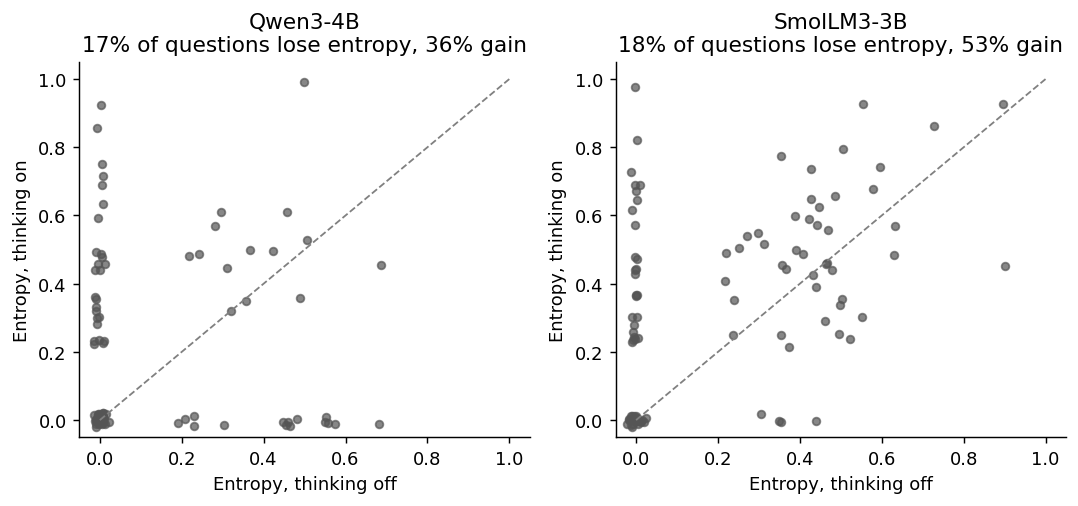

In [20]:
# Figure 2: per-question entropy, thinking off vs on (points below the diagonal = collapse under reasoning)
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(4.2 * len(MODEL_ORDER), 4), squeeze=False)
for ax, m in zip(axes[0], MODEL_ORDER):
    w = qdf[qdf.model == m].pivot(index="qkey", columns="condition", values="entropy").dropna()
    if not len(w): continue
    ax.scatter(w["no_think"] + rng.normal(0, .01, len(w)), w["think"] + rng.normal(0, .01, len(w)),
               s=18, alpha=.7, color="#555")
    ax.plot([0, 1], [0, 1], color="gray", ls="--", lw=1)
    below = (w["think"] < w["no_think"]).mean(); above = (w["think"] > w["no_think"]).mean()
    ax.set_title(f"{m}\n{below:.0%} of questions lose entropy, {above:.0%} gain")
    ax.set_xlabel("Entropy, thinking off"); ax.set_ylabel("Entropy, thinking on")
    ax.set_xlim(-.05, 1.05); ax.set_ylim(-.05, 1.05)
fig.tight_layout(); savefig(fig, "fig2_entropy_scatter"); plt.show()

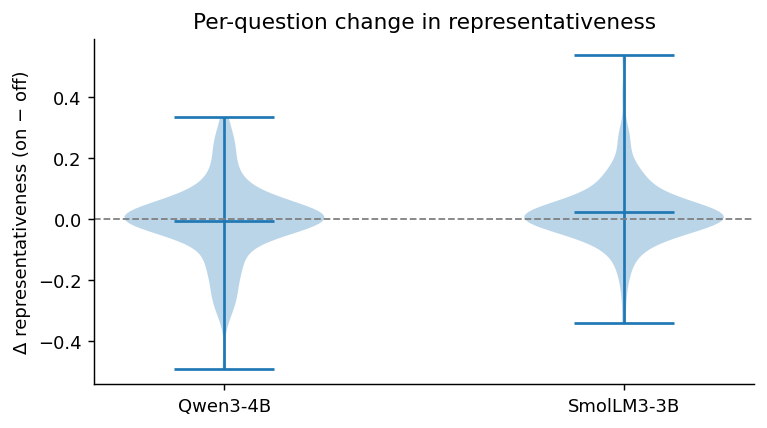

In [21]:
# Figure 3: distribution of the per-question difference in representativeness
fig, ax = plt.subplots(figsize=(6, 3.4))
data = [qdf[qdf.model == m].pivot(index="qkey", columns="condition", values="rep").dropna() for m in MODEL_ORDER]
data = [(d["think"] - d["no_think"]).values for d in data]
parts = ax.violinplot([d if len(d) else [0] for d in data], showmeans=True)
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xticks(range(1, len(MODEL_ORDER) + 1)); ax.set_xticklabels(MODEL_ORDER)
ax.set_ylabel("Δ representativeness (on − off)")
ax.set_title("Per-question change in representativeness")
fig.tight_layout(); savefig(fig, "fig3_rep_diff"); plt.show()

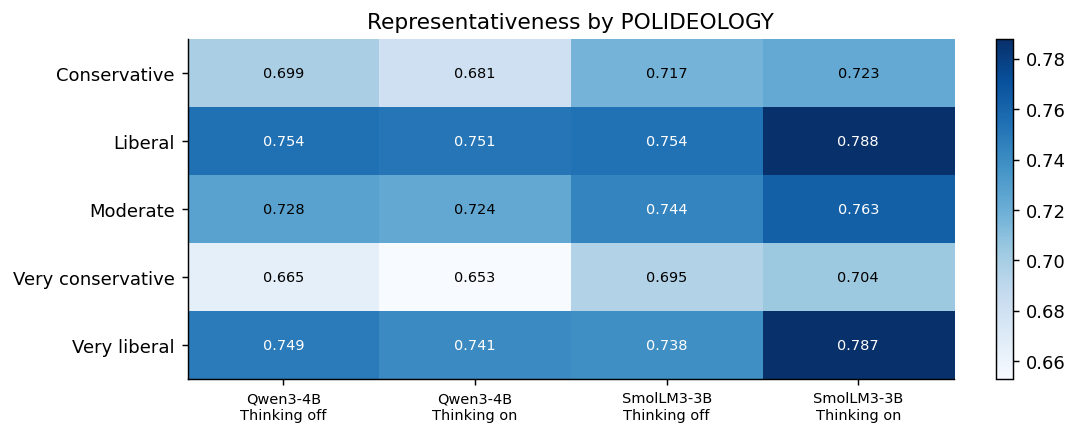

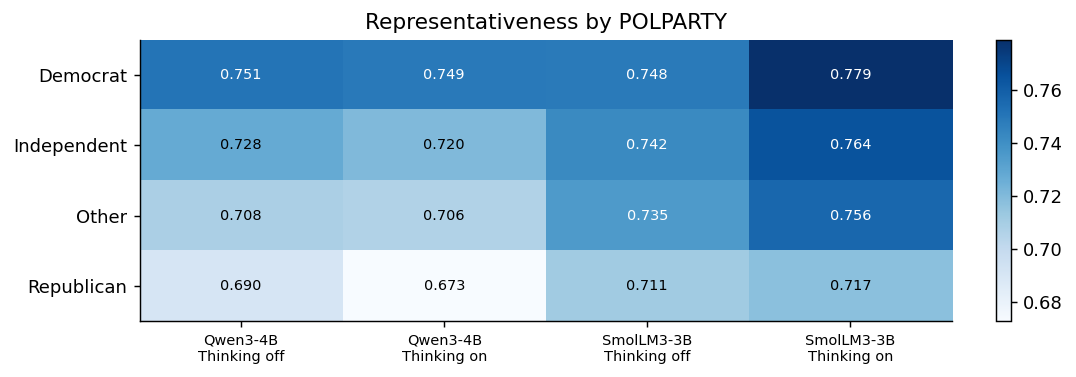

In [22]:
# Figure 4: subgroup representativeness for political ideology and party
for attr in ["POLIDEOLOGY", "POLPARTY"]:
    if attr not in group_rep.index.get_level_values(0): continue
    t = group_rep.loc[attr]
    md_opts = GROUP_ORDER.get(attr, [])
    t = t.reindex([g for g in md_opts if g in t.index] + [g for g in t.index if g not in md_opts])
    fig, ax = plt.subplots(figsize=(1.6 * t.shape[1] + 2, 0.45 * len(t) + 1.2))
    im = ax.imshow(t.values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(t.shape[1])); ax.set_xticklabels([f"{m}\n{COND_LABEL[c]}" for m, c in t.columns], fontsize=8)
    ax.set_yticks(range(len(t))); ax.set_yticklabels(t.index)
    for i in range(t.shape[0]):
        for j in range(t.shape[1]):
            ax.text(j, i, f"{t.values[i, j]:.3f}", ha="center", va="center", fontsize=8,
                    color="white" if t.values[i, j] > np.nanmean(t.values) else "black")
    ax.set_title(f"Representativeness by {attr}")
    fig.colorbar(im, ax=ax, fraction=0.04)
    fig.tight_layout(); savefig(fig, f"fig4_groups_{attr}"); plt.show()

In [23]:
# (one-off cleanup cell, already run: backed up and removed the first no-think generations, which used a 64-token limit)

## 10. Summary for the paper
A plain-language readout of the main table, to copy into the Results section (check the numbers against the tables).

In [24]:
def fmt_p(p): return "p < .001" if p < .001 else f"p = {p:.3f}"
lines = []
for m in MODEL_ORDER:
    t = main[main.model == m].set_index("metric")
    if "entropy" not in t.index: continue
    e, r, s = t.loc["entropy"], t.loc["rep"], t.loc["modal_share"]
    direction = "less" if e["diff"] < 0 else ("more" if e["diff"] > 0 else "equally")
    lines.append(
        f"{m}: with thinking on, answers were {direction} diverse (normalised entropy {e.no_think:.3f} → {e.think:.3f}, "
        f"Δ = {e['diff']:+.3f}, 95% CI [{e.ci_low:+.3f}, {e.ci_high:+.3f}], Holm-{fmt_p(e.p_holm)}); "
        f"modal share {s.no_think:.3f} → {s.think:.3f}; representativeness {r.no_think:.3f} → {r.think:.3f} "
        f"(Δ = {r['diff']:+.3f}, 95% CI [{r.ci_low:+.3f}, {r.ci_high:+.3f}], Holm-{fmt_p(r.p_holm)}). "
        f"Entropy fell on {e.share_q_down:.0%} of questions and rose on {e.share_q_up:.0%}.")
lines.append(f"Reference: a calibrated model drawing {N_SAMPLES} answers from the human distribution would score "
             f"entropy {hbase.entropy.mean():.3f}, modal share {hbase.modal_share.mean():.3f}, "
             f"representativeness {hbase.rep.mean():.3f}.")
summary = "\n\n".join(lines)
open(os.path.join(OUT_DIR, "summary.txt"), "w").write(summary)
print(summary)
if SMOKE_TEST:
    print("\n*** SMOKE TEST ONLY: numbers are meaningless. Set SMOKE_TEST = False and re-run for the real results. ***")

Qwen3-4B: with thinking on, answers were more diverse (normalised entropy 0.121 → 0.194, Δ = +0.074, 95% CI [+0.012, +0.136], Holm-p = 0.060); modal share 0.928 → 0.874; representativeness 0.724 → 0.717 (Δ = -0.007, 95% CI [-0.032, +0.018], Holm-p = 0.976). Entropy fell on 17% of questions and rose on 36%.

SmolLM3-3B: with thinking on, answers were more diverse (normalised entropy 0.211 → 0.344, Δ = +0.133, 95% CI [+0.082, +0.186], Holm-p < .001); modal share 0.867 → 0.799; representativeness 0.736 → 0.759 (Δ = +0.023, 95% CI [+0.001, +0.046], Holm-p = 0.041). Entropy fell on 18% of questions and rose on 53%.

Reference: a calibrated model drawing 10 answers from the human distribution would score entropy 0.738, modal share 0.544, representativeness 0.902.


In [25]:
# LaTeX table for the paper (main results)
tex = main[main.metric != "refusal"][["model", "metric", "no_think", "think", "diff", "ci_low", "ci_high", "p_holm"]].copy()
tex["metric"] = tex.metric.map({**LABELS, "refusal": "Refusal"})
tex["95% CI"] = tex.apply(lambda r: f"[{r.ci_low:+.3f}, {r.ci_high:+.3f}]", axis=1)
tex = tex.rename(columns={"no_think": "Off", "think": "On", "diff": "Δ", "p_holm": "p (Holm)"})
tex = tex[["model", "metric", "Off", "On", "Δ", "95% CI", "p (Holm)"]]
open(os.path.join(TAB_DIR, "main_results.tex"), "w").write(tex.to_latex(index=False, float_format="%.3f"))
print("Saved all tables to", TAB_DIR, "and figures to", FIG_DIR)

Saved all tables to /content/opinionqa_reasoning/q100_k10/tables and figures to /content/opinionqa_reasoning/q100_k10/figures


In [26]:
for _, r in main.iterrows(): print(f"{r.model[:4]} {r.metric[:8]:8} off={r.no_think:.3f} on={r.think:.3f} d={r['diff']:+.3f} [{r.ci_low:+.3f},{r.ci_high:+.3f}] p={r.p_holm:.4f} n={r.n_q}")

Qwen rep      off=0.724 on=0.717 d=-0.007 [-0.032,+0.018] p=0.9758 n=98
Qwen entropy  off=0.121 on=0.194 d=+0.074 [+0.012,+0.136] p=0.0603 n=98
Qwen modal_sh off=0.928 on=0.874 d=-0.054 [-0.094,-0.013] p=0.0502 n=98
Qwen distinct off=1.327 on=1.490 d=+0.163 [+0.000,+0.327] p=0.1621 n=98
Qwen refusal  off=0.029 on=0.103 d=+0.074 [+0.029,+0.123] p=0.0093 n=100
Smol rep      off=0.736 on=0.759 d=+0.023 [+0.001,+0.046] p=0.0414 n=99
Smol entropy  off=0.211 on=0.344 d=+0.133 [+0.082,+0.186] p=0.0001 n=99
Smol modal_sh off=0.867 on=0.799 d=-0.069 [-0.105,-0.032] p=0.0010 n=99
Smol distinct off=1.525 on=1.960 d=+0.434 [+0.303,+0.576] p=0.0000 n=99
Smol refusal  off=0.001 on=0.022 d=+0.021 [+0.005,+0.046] p=0.1399 n=100


In [27]:
print(qdf.groupby(['model','condition'])[['parse_fail','refusal','truncated','n_valid','gen_tokens']].mean().round(3).to_string()); print('N_Q', main.groupby('model').n_q.max().to_dict()); print('HB', hbase[['rep','entropy','modal_share','distinct']].mean().round(3).to_dict(), 'TRUE', hbase_true[['entropy','modal_share']].mean().round(3).to_dict()); [print(f"POOL {r.metric[:8]:8} d={r['diff']:+.3f} [{r.ci_low:+.3f},{r.ci_high:+.3f}] p={r.p_holm:.4f}") for _, r in pooled.iterrows()]; [print(f"ROB {r.check[:6]} {r.model[:4]} {r.metric[:8]:8} d={r['diff']:+.3f} [{r.ci_low:+.3f},{r.ci_high:+.3f}] p={r.p_holm:.3f} n={r.n_q}") for _, r in robust.iterrows()]; print(corr.round(3).to_string())

                      parse_fail  refusal  truncated  n_valid  gen_tokens
model      condition                                                     
Qwen3-4B   no_think        0.000    0.029      0.000    9.710      34.791
           think           0.000    0.103      0.004    8.970     599.859
SmolLM3-3B no_think        0.000    0.001      0.000    9.990      95.413
           think           0.000    0.022      0.016    9.780     567.866
N_Q {'Qwen3-4B': 100, 'SmolLM3-3B': 100}
HB {'rep': 0.902, 'entropy': 0.738, 'modal_share': 0.544, 'distinct': 3.112} TRUE {'entropy': 0.851, 'modal_share': 0.48}
POOL rep      d=+0.008 [-0.010,+0.026] p=0.5182
POOL entropy  d=+0.104 [+0.060,+0.148] p=0.0001
POOL modal_sh d=-0.062 [-0.092,-0.033] p=0.0004
POOL distinct d=+0.298 [+0.187,+0.414] p=0.0000
POOL refusal  d=+0.048 [+0.023,+0.074] p=0.0012
ROB no tru Qwen rep      d=-0.007 [-0.032,+0.018] p=1.000 n=98
ROB no tru Qwen entropy  d=+0.073 [+0.011,+0.135] p=0.101 n=98
ROB no tru Qwen modal_sh d=

In [28]:
import shutil; z = shutil.make_archive('/content/opinionqa_reasoning_results', 'zip', OUT_DIR); print(z, round(os.path.getsize(z)/1e6, 1), 'MB')

/content/opinionqa_reasoning_results.zip 3.1 MB
